# Лабораторная работа №4


In [26]:
import  pandas as pd

In [27]:
train = pd.read_csv('train.csv').drop(columns=['Unnamed: 0'])
test = pd.read_csv('test.csv').drop(columns=['Unnamed: 0'])

In [28]:
train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
0,5.140,7.71660,21634.909,201.516309,8497.497,175.278,175.278,704.972,2.078,11.004,24.951,0.494,0.965,2.0,0.994
1,1.138,1.54332,2706.698,138.966361,6622.351,6.270,6.270,545.800,1.184,6.450,26.222,0.194,0.975,0.0,0.979
2,7.148,10.80324,38998.248,280.444531,9120.644,332.275,332.275,835.034,2.980,15.730,44.789,0.887,0.976,3.0,0.977
3,1.138,1.54332,6763.006,144.782287,6697.636,9.375,9.375,620.925,1.322,7.078,0.000,0.278,0.982,0.0,1.000
4,8.206,12.34656,50994.067,323.324443,9319.460,438.106,438.106,917.854,3.566,18.180,59.577,1.179,0.964,3.0,0.999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9542,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.018,3.607,18.693,60.083,1.189,0.998,3.0,0.980
9543,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.160,3.589,18.621,61.190,1.211,0.972,3.0,0.979
9544,9.300,13.88988,72759.686,372.841179,9751.200,644.872,644.872,1089.292,4.526,22.961,90.760,1.797,0.973,3.0,0.975
9545,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.989,2.497,13.129,34.453,0.682,0.953,2.0,0.992


### Поиск и обработка выбросов

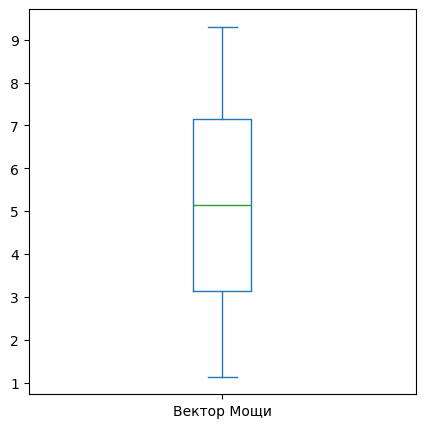

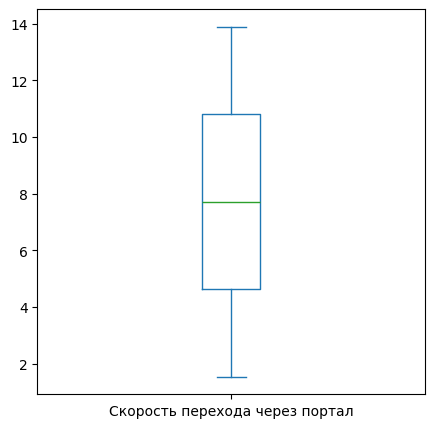

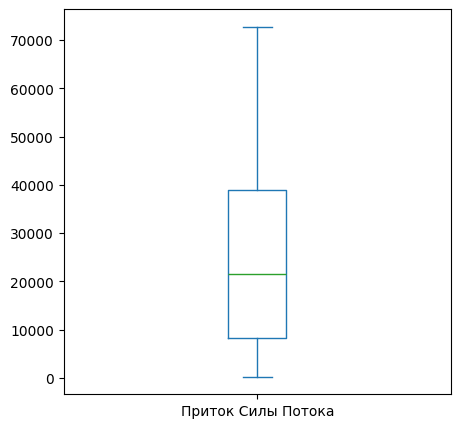

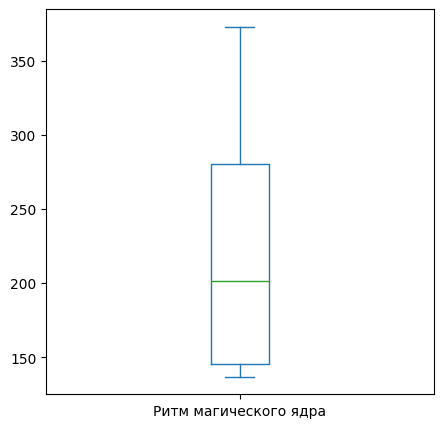

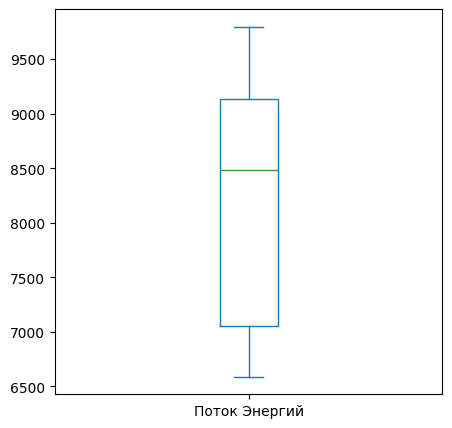

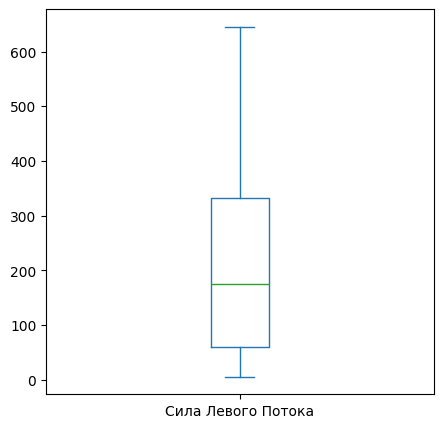

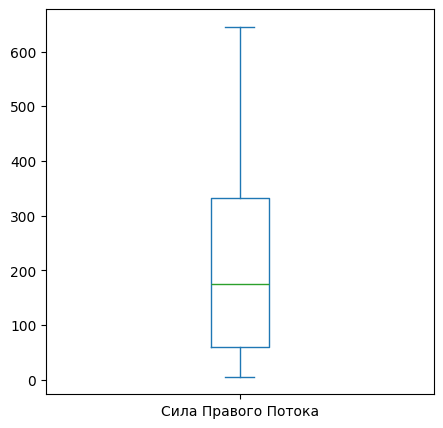

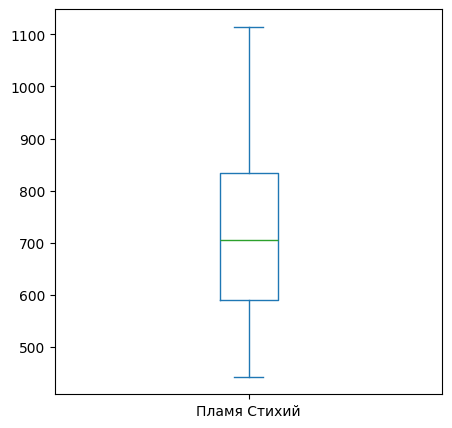

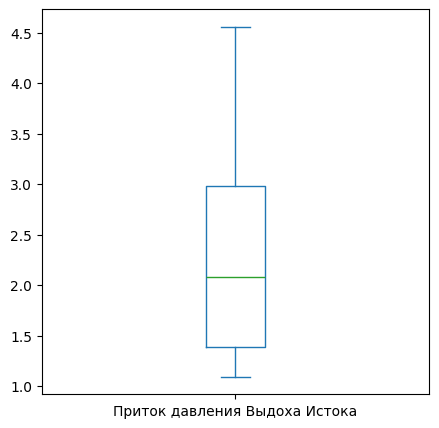

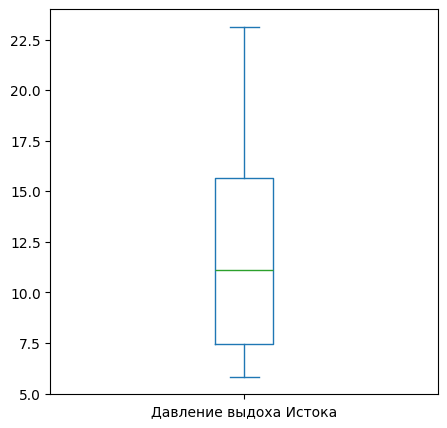

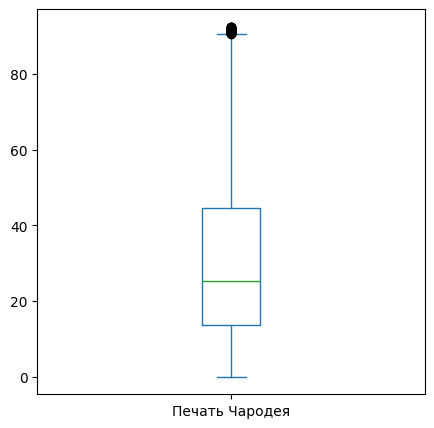

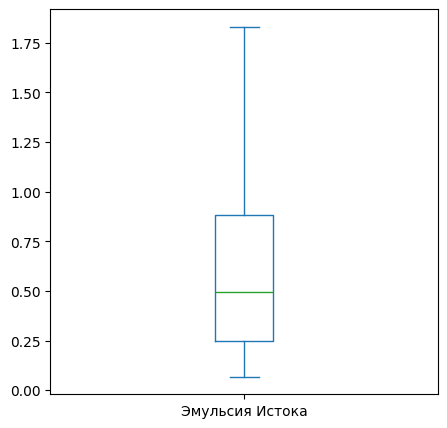

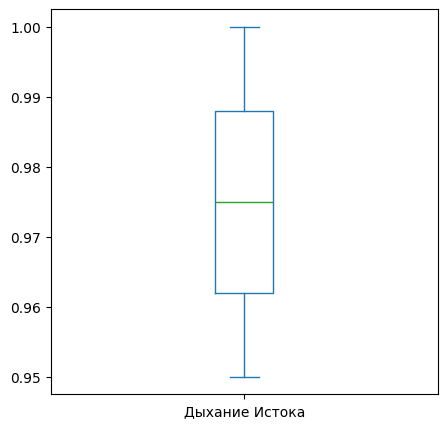

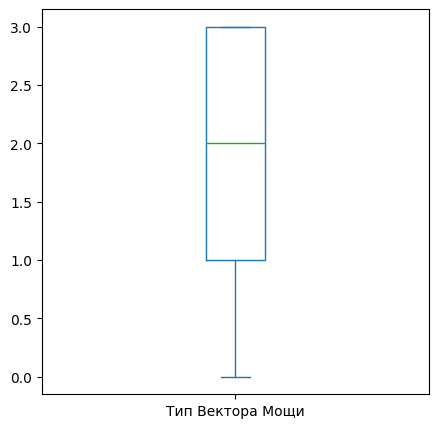

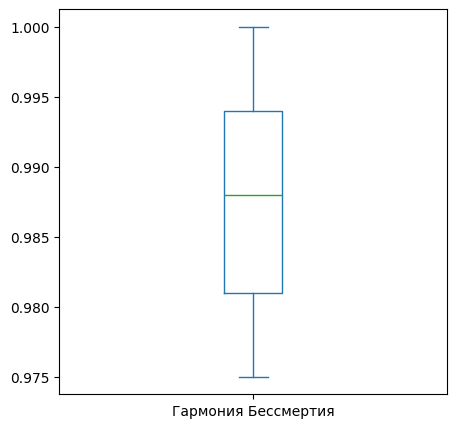

In [29]:
import matplotlib.pyplot as plt

for col in train.columns:
    plt.figure(figsize=[5,5]);
    train[col].plot(kind='box')


### Вывод:
Выбросы наблюдаются в признаке ```Печать Чародея```

#### Обработка выбросов


In [30]:
#IQR
def iqr(df : pd.DataFrame, column: str) -> pd.DataFrame:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[(df[column] < lower) | (df[column] >  upper)]

In [31]:
emiss_column = 'Печать Чародея'
emiss_iqr = iqr(train, emiss_column)

In [32]:
emiss_iqr

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
15,9.3,13.88988,72774.949,372.848195,9788.415,644.979,644.979,1099.234,4.481,22.390,90.712,1.796,0.952,3.0,0.991
19,9.3,13.88988,72762.555,372.843064,9764.719,644.784,644.784,1098.829,4.511,22.841,91.319,1.808,0.963,3.0,0.977
48,9.3,13.88988,72771.424,372.846311,9778.933,645.076,645.076,1097.754,4.493,22.556,90.838,1.798,0.957,3.0,0.986
60,9.3,13.88988,72762.377,372.842855,9769.808,644.932,644.932,1105.506,4.506,22.836,91.817,1.818,0.958,3.0,0.976
203,9.3,13.88988,72767.398,372.845996,9780.868,645.036,645.036,1108.034,4.493,22.660,91.758,1.816,0.952,3.0,0.981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9399,9.3,13.88988,72769.109,372.845054,9777.762,645.092,645.092,1101.569,4.495,22.631,91.231,1.806,0.956,3.0,0.983
9423,9.3,13.88988,72766.613,372.844216,9768.017,645.088,645.088,1095.246,4.507,22.731,90.894,1.799,0.963,3.0,0.981
9458,9.3,13.88988,72769.034,372.845682,9780.085,645.074,645.074,1103.906,4.493,22.618,91.389,1.809,0.954,3.0,0.983
9465,9.3,13.88988,72775.917,372.848405,9791.421,644.946,644.946,1100.727,4.477,22.350,90.768,1.797,0.950,3.0,0.992


In [ ]:
#Robust Z-score
from scipy import stats
import numpy as np
def robust_zscore(df: pd.DataFrame, col: str) -> pd.Series:
    median = df[col].median()
    mad = stats.median_abs_deviation(df[col], scale='normal')
    if mad ==0:
        mad = 1e-9
    z_score = (df[col] - median)/mad

    outliers = np.abs(z_score) > 3 
    return outliers

In [34]:
emiss_robust = robust_zscore(train, emiss_column)

In [35]:
emiss_robust = train[emiss_robust]

In [36]:
emiss_robust

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
9,9.3,13.88988,72763.303,372.841912,9738.873,644.962,644.962,1063.563,4.538,22.854,88.590,1.754,0.990,3.0,0.983
15,9.3,13.88988,72774.949,372.848195,9788.415,644.979,644.979,1099.234,4.481,22.390,90.712,1.796,0.952,3.0,0.991
19,9.3,13.88988,72762.555,372.843064,9764.719,644.784,644.784,1098.829,4.511,22.841,91.319,1.808,0.963,3.0,0.977
21,9.3,13.88988,72770.614,372.845054,9758.963,644.801,644.801,1074.439,4.514,22.626,89.137,1.765,0.976,3.0,0.988
48,9.3,13.88988,72771.424,372.846311,9778.933,645.076,645.076,1097.754,4.493,22.556,90.838,1.798,0.957,3.0,0.986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9519,9.3,13.88988,72756.427,372.839818,9734.857,644.815,644.815,1073.897,4.544,23.053,89.675,1.775,0.987,3.0,0.975
9520,9.3,13.88988,72762.710,372.842226,9732.841,644.732,644.732,1054.368,4.544,22.846,87.848,1.739,0.997,3.0,0.985
9530,9.3,13.88988,72758.486,372.841179,9730.414,644.760,644.760,1060.879,4.548,22.969,88.530,1.752,0.995,3.0,0.980
9536,9.3,13.88988,72769.245,372.843588,9737.897,644.840,644.840,1045.364,4.538,22.643,86.861,1.719,0.999,3.0,0.993


#### Объединение

In [15]:
intersection_index = emiss_robust.index.intersection(emiss_iqr.index)
total = emiss_robust.loc[intersection_index]

In [16]:
total

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
15,9.3,13.88988,72774.949,372.848195,9788.415,644.979,644.979,1099.234,4.481,22.390,90.712,1.796,0.952,3.0,0.991
19,9.3,13.88988,72762.555,372.843064,9764.719,644.784,644.784,1098.829,4.511,22.841,91.319,1.808,0.963,3.0,0.977
48,9.3,13.88988,72771.424,372.846311,9778.933,645.076,645.076,1097.754,4.493,22.556,90.838,1.798,0.957,3.0,0.986
60,9.3,13.88988,72762.377,372.842855,9769.808,644.932,644.932,1105.506,4.506,22.836,91.817,1.818,0.958,3.0,0.976
203,9.3,13.88988,72767.398,372.845996,9780.868,645.036,645.036,1108.034,4.493,22.660,91.758,1.816,0.952,3.0,0.981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9399,9.3,13.88988,72769.109,372.845054,9777.762,645.092,645.092,1101.569,4.495,22.631,91.231,1.806,0.956,3.0,0.983
9423,9.3,13.88988,72766.613,372.844216,9768.017,645.088,645.088,1095.246,4.507,22.731,90.894,1.799,0.963,3.0,0.981
9458,9.3,13.88988,72769.034,372.845682,9780.085,645.074,645.074,1103.906,4.493,22.618,91.389,1.809,0.954,3.0,0.983
9465,9.3,13.88988,72775.917,372.848405,9791.421,644.946,644.946,1100.727,4.477,22.350,90.768,1.797,0.950,3.0,0.992


In [37]:
train_without_emiss = train.drop(intersection_index)

In [38]:
train_without_emiss = train_without_emiss.reset_index(drop=True)

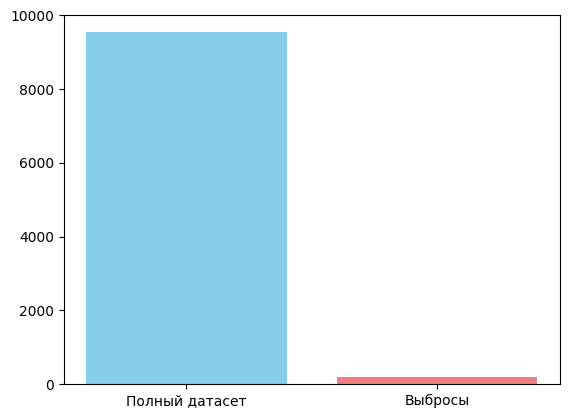

In [40]:
#Визуализация
data = {
    'Dataset': ['Полный датасет', 'Выбросы'],
    'Строки': [train.shape[0], total.shape[0]]
}

comparison_df = pd.DataFrame(data)

plt.bar(comparison_df['Dataset'], comparison_df['Строки'], color = ['skyblue', 'lightcoral'])
plt.show()